# <center><u>Trader Performance vs Market Sentiment Analysis</u></center>

## Objective
The goal of this analysis is to understand how market sentiment (Fear vs Greed) influences trader behavior and performance on Hyperliquid.

We aim to:
- Analyze differences in trader profitability across sentiment regimes
- Study behavioral changes such as trading frequency, position size, and activity
- Identify meaningful trader segments
- Derive actionable trading strategies based on insights

## Datasets Used

1. **Bitcoin Market Sentiment Dataset**
   - Contains daily sentiment classification (Fear, Greed, etc.)

2. **Hyperliquid Trader Data**
   - Includes trade-level data such as price, size, PnL, timestamps, etc.

## Key Questions

- Does trader performance vary between Fear and Greed markets?
- Do traders behave differently depending on sentiment?
- Can we identify profitable trading patterns or segments?

## Approach

1. Data Cleaning & Preparation  
2. Feature Engineering  
3. Exploratory Data Analysis  
4. Behavioral & Performance Analysis  
5. Insights & Strategy Recommendations

---

## Part A — Data Preparation

This section focuses on:
- Loading and understanding the datasets
- Cleaning and validating data quality
- Converting timestamps and aligning datasets
- Creating key metrics required for analysis

In [1]:
# Load Datasets
import pandas as pd
import numpy as np

fg = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [2]:
# Dataset Overview
print("Fear/Greed Shape:", fg.shape)
print("Trader Data Shape:", trades.shape)

print("\nFear/Greed Columns:\n", fg.columns.tolist())
print("\nTrader Columns:\n", trades.columns.tolist())

Fear/Greed Shape: (2644, 4)
Trader Data Shape: (211224, 16)

Fear/Greed Columns:
 ['timestamp', 'value', 'classification', 'date']

Trader Columns:
 ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [3]:
# Missing Values & Duplicates
print("\nMissing Values (Fear/Greed):\n", fg.isnull().sum())
print("\nMissing Values (Trades):\n", trades.isnull().sum())

print("\nDuplicate Rows (Fear/Greed):", fg.duplicated().sum())
print("Duplicate Rows (Trades):", trades.duplicated().sum())


Missing Values (Fear/Greed):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows (Fear/Greed): 0
Duplicate Rows (Trades): 0


In [4]:
# Convert timestamp (milliseconds → datetime)
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

# Extract date
trades['date'] = trades['Timestamp'].dt.date

# Convert sentiment date
fg['date'] = pd.to_datetime(fg['date']).dt.date

In [5]:
print(trades[['Timestamp', 'date']].head())
print("\nUnique Dates (Trades):", trades['date'].nunique())
print("Unique Dates (Sentiment):", fg['date'].nunique())

            Timestamp        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27

Unique Dates (Trades): 7
Unique Dates (Sentiment): 2644


In [6]:
merged_data = pd.merge(
    trades,
    fg[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged Shape:", merged_data.shape)
print("Missing Sentiment:", merged_data['classification'].isnull().sum())

Merged Shape: (211224, 18)
Missing Sentiment: 26961


In [7]:
# Keep only overlapping dates
merged_data = merged_data.dropna(subset=['classification'])

print("After Cleaning Shape:", merged_data.shape)

After Cleaning Shape: (184263, 18)


In [8]:
# Profit flag
merged_data['is_profit'] = merged_data['Closed PnL'] > 0

# Long/Short flag
merged_data['is_long'] = merged_data['Side'].str.lower() == 'buy'

In [9]:
# Aggregate Metrics
daily_metrics = merged_data.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trades_count=('Trade ID', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'),
    win_rate=('is_profit', 'mean')
).reset_index()

In [10]:
# Long/Short Ratio
long_short = merged_data.groupby(['date', 'Account']).agg(
    long_ratio=('is_long', 'mean')
).reset_index()

daily_metrics = pd.merge(daily_metrics, long_short, on=['date', 'Account'])

In [11]:
# Add Sentiment Back
sentiment_map = merged_data[['date', 'classification']].drop_duplicates()

daily_metrics = pd.merge(
    daily_metrics,
    sentiment_map,
    on='date',
    how='left'
)

In [12]:
print(daily_metrics.head())
print("\nShape:", daily_metrics.shape)

         date                                     Account    daily_pnl  \
0  2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   
1  2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   
2  2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   155.503357   
3  2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -5564.016140   
4  2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713     0.000000   

   trades_count  avg_trade_size  total_volume  win_rate  long_ratio  \
0             3      159.000000        477.00  0.000000    1.000000   
1             2    23066.935000      46133.87  0.000000    1.000000   
2          1043    11034.799511   11509295.89  0.275168    0.468840   
3            27     3048.594444      82312.05  0.333333    0.148148   
4            88     1136.312727      99995.52  0.000000    1.000000   

  classification  
0          Greed  
1          Greed  
2          Greed  
3  Extreme Greed  
4  Extreme Greed  

Shape: (77, 9

### Data Quality & Overview
- The **Fear/Greed dataset** contains **2,644 rows and 4 columns**, representing daily market sentiment.
- The **trader dataset** contains **211,224 rows and 16 columns**, with detailed trade-level data.

### Data Quality Checks
- No missing values were found in either dataset
- No duplicate records detected

* This confirms that both datasets are **clean and reliable for analysis**

### Timestamp Conversion & Alignment
- The trader dataset contained timestamps in **Unix format (milliseconds)**, which were converted into readable datetime format.
- A new `date` column was extracted to align data at a **daily level**.

### Key Observation
- Trader dataset spans only **7 unique dates**
- Sentiment dataset spans **2644 dates**

* This indicates **limited overlap between datasets**

### Data Merging

- The datasets were merged on the `date` column to map each trade with market sentiment.

### Merge Outcome
- Initial merge resulted in **26,961 rows without sentiment labels**
- These rows were removed to ensure accuracy

### Final Dataset
- After cleaning: **184,263 rows**
- Only valid trade-sentiment mappings retained

### Feature Engineering

* To enable meaningful analysis, trade-level data was aggregated into **daily trader-level metrics**.

### Key Metrics Created
- **Daily PnL** → Measures profitability per trader per day  
- **Win Rate** → Fraction of profitable trades  
- **Number of Trades** → Trading activity level  
- **Average Trade Size** → Risk-taking behavior  
- **Total Volume** → Total capital exposure  
- **Long/Short Ratio** → Directional bias (long vs short positions)  

### Final Prepared Dataset
- Final dataset contains **77 trader-day observations**
- Each row represents a trader’s behavior and performance for a specific day

### Key Observations
- The dataset is relatively small after alignment due to limited overlapping dates
- Despite this, it captures **rich behavioral and performance metrics**
- The data is well-structured and suitable for analyzing the relationship between **market sentiment and trader behavior**

### Note on Leverage
- Explicit leverage data was not available in the dataset
- **Average trade size** is used as a proxy for risk exposure

---

## Part B — Analysis

This section evaluates how trader performance and behavior change across different market sentiment regimes (Fear vs Greed).

We analyze:
- Performance (PnL, Win Rate, Drawdown proxy)
- Behavioral changes (activity, trade size, direction)
- Trader segmentation
- Key insights supported by visual evidence

## 1. Performance Analysis: Fear vs Greed

In [13]:
#Code (PnL + Win Rate)
# Summary stats
performance_summary = daily_metrics.groupby('classification').agg(
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean')
).reset_index()

print(performance_summary)

  classification        avg_pnl    median_pnl  avg_win_rate
0  Extreme Greed   35393.098355      0.000000      0.336609
1           Fear  209372.662205  81389.682515      0.415878
2          Greed   99675.516731  35988.376437      0.374074
3        Neutral   19842.797260     -0.418640      0.260683


C:\Users\Admin\AppData\Local\Temp\ipykernel_10088\239534062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


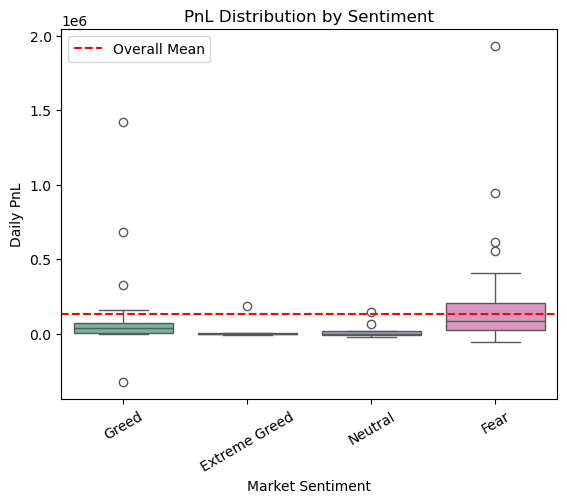

In [39]:
#Visualization (PnL)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(
    x='classification',
    y='daily_pnl',
    data=daily_metrics,
    palette='Set2'
)

plt.axhline(daily_metrics['daily_pnl'].mean(), color='red', linestyle='--', label='Overall Mean')

plt.title("PnL Distribution by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")

plt.legend()
plt.xticks(rotation=30)
plt.savefig('PnL Distribution by Sentiment.png', dpi=300)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10088\1993781111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


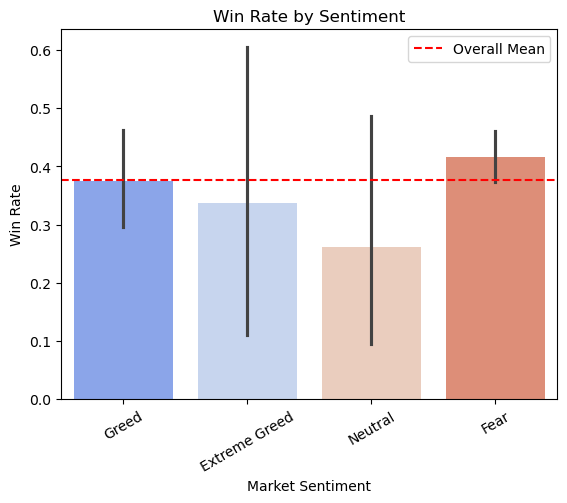

In [40]:
# Visualization (Win Rate)
plt.figure()

sns.barplot(
    x='classification',
    y='win_rate',
    data=daily_metrics,
    palette='coolwarm'
)

plt.axhline(daily_metrics['win_rate'].mean(), color='red', linestyle='--', label='Overall Mean')

plt.title("Win Rate by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.legend()
plt.xticks(rotation=30)
plt.savefig('Win Rate by Sentiment.png', dpi=300)
plt.show()

### Evidence (PnL & Win Rate)

| Sentiment        | Avg PnL | Median PnL | Avg Win Rate |
|-----------------|--------|------------|--------------|
| Fear            | **209,372** | **81,389** | **0.416** |
| Greed           | 99,675 | 35,988 | 0.374 |
| Extreme Greed   | 35,393 | 0 | 0.337 |
| Neutral         | 19,842 | ~0 | 0.261 |


### Key Findings
- **Fear markets show the highest performance**:
  - Highest average PnL (~209K)
  - Highest median PnL (~81K)
  - Highest win rate (~41.6%)

- **Extreme Greed shows weak performance**:
  - Median PnL ≈ 0 → inconsistent profitability
  - Lower win rate

- **Neutral markets perform worst overall**:
  - Lowest PnL and win rate (~26%)


### Drawdown Proxy
- Negative and near-zero median PnL observed in:
  - **Extreme Greed**
  - **Neutral markets**

Indicates higher downside risk and inconsistency


### Conclusion
- **Fear → High profitability + higher win rate**
- **Greed → Moderate performance**
- **Extreme Greed & Neutral → Lower and inconsistent performance**

Market sentiment strongly impacts trader profitability.

---

## 2. Behavioral Changes Across Sentiment

In [15]:
behavior_summary = daily_metrics.groupby('classification').agg(
    avg_trades=('trades_count', 'mean'),
    avg_size=('avg_trade_size', 'mean'),
    avg_long_ratio=('long_ratio', 'mean')
).reset_index()

print(behavior_summary)

  classification  avg_trades     avg_size  avg_long_ratio
0  Extreme Greed  1392.40000  4344.447836        0.518479
1           Fear  4183.46875  5926.522723        0.459352
2          Greed  1134.03125  5839.310974        0.495780
3        Neutral   892.62500  3793.444161        0.468967


C:\Users\Admin\AppData\Local\Temp\ipykernel_10088\1928127835.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


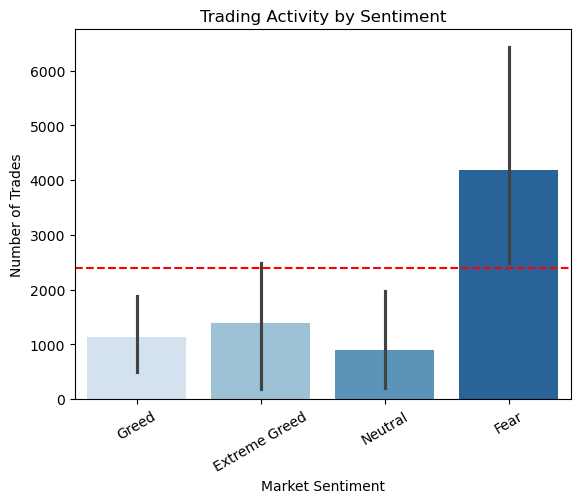

In [41]:
# Visualization (Trade Frequency
plt.figure()

sns.barplot(
    x='classification',
    y='trades_count',
    data=daily_metrics,
    palette='Blues'
)

plt.axhline(daily_metrics['trades_count'].mean(), color='red', linestyle='--')

plt.title("Trading Activity by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=30)
plt.savefig('Trading Activity by Sentiment.png', dpi=300)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10088\4221690316.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


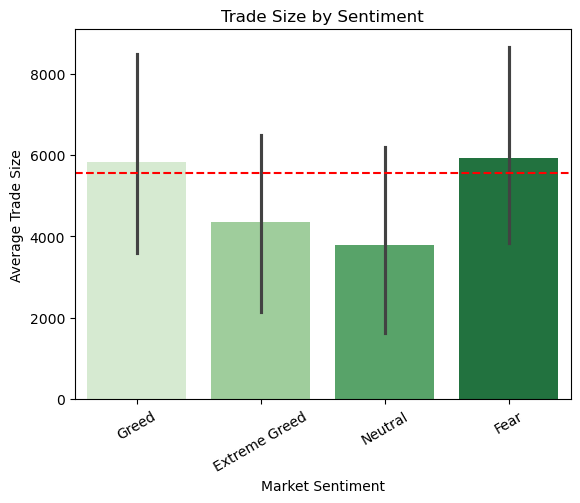

In [42]:
# Visualization (Trade Size)
plt.figure()

sns.barplot(
    x='classification',
    y='avg_trade_size',
    data=daily_metrics,
    palette='Greens'
)

plt.axhline(daily_metrics['avg_trade_size'].mean(), color='red', linestyle='--')

plt.title("Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size")

plt.xticks(rotation=30)
plt.savefig('Trade Size by Sentiment.png', dpi=300)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10088\1544709766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


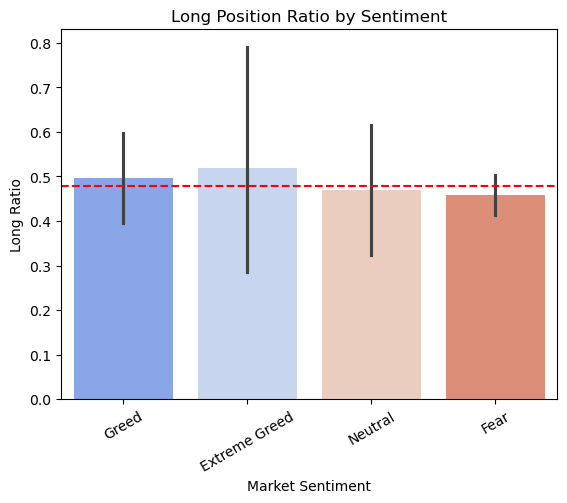

In [43]:
# Visualization (Long/Short)
plt.figure()

sns.barplot(
    x='classification',
    y='long_ratio',
    data=daily_metrics,
    palette='coolwarm'
)

plt.axhline(daily_metrics['long_ratio'].mean(), color='red', linestyle='--')

plt.title("Long Position Ratio by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long Ratio")

plt.xticks(rotation=30)
plt.savefig('Long Position Ratio by Sentiment.png', dpi=300)
plt.show()

### Evidence

| Sentiment        | Avg Trades | Avg Trade Size | Long Ratio |
|-----------------|-----------|----------------|-----------|
| Fear            | **4183** | **5926** | 0.459 |
| Greed           | 1134 | 5839 | 0.496 |
| Extreme Greed   | 1392 | 4344 | 0.518 |
| Neutral         | 892 | 3793 | 0.469 |


### Key Findings

#### Trading Activity
- Highest during **Fear (~4183 trades)**  
- Lowest during **Neutral (~892 trades)**  

Traders are significantly more active in volatile (fearful) markets

#### Trade Size (Risk Behavior)
- Largest during **Fear (~5926 USD)**  
- Decreases in Neutral and Extreme Greed  

Traders take **larger positions during uncertainty**

#### Long/Short Bias
- Slightly higher long bias in **Extreme Greed (~0.52)**
- More balanced positions during Fear (~0.46)

Traders become **more bullish during Greed phases**


### Conclusion
- **Fear → High activity + high risk-taking**
- **Greed → Moderate activity + bullish bias**
- **Neutral → Low engagement**

Market sentiment directly influences trader behavior.

---

## 3. Trader Segmentation

In [19]:
# Create Segmentation Columns
# Activity segment
daily_metrics['activity_segment'] = np.where(
    daily_metrics['trades_count'] > daily_metrics['trades_count'].median(),
    'High Activity',
    'Low Activity'
)

# Risk segment (proxy using trade size)
daily_metrics['risk_segment'] = np.where(
    daily_metrics['avg_trade_size'] > daily_metrics['avg_trade_size'].median(),
    'High Risk',
    'Low Risk'
)

# Performance segment
daily_metrics['performance_segment'] = np.where(
    daily_metrics['daily_pnl'] > 0,
    'Profitable',
    'Loss Making'
)

In [20]:
print(daily_metrics[['activity_segment', 'risk_segment', 'performance_segment']].head())

  activity_segment risk_segment performance_segment
0     Low Activity     Low Risk         Loss Making
1     Low Activity    High Risk         Loss Making
2    High Activity    High Risk          Profitable
3     Low Activity    High Risk         Loss Making
4     Low Activity     Low Risk         Loss Making


In [21]:
segment_analysis = daily_metrics.groupby(
    ['classification', 'activity_segment', 'risk_segment']
).agg(
    avg_pnl=('daily_pnl', 'mean'),
    count=('Account', 'count')
).reset_index()

print(segment_analysis)

   classification activity_segment risk_segment        avg_pnl  count
0   Extreme Greed    High Activity    High Risk   95224.489473      2
1   Extreme Greed     Low Activity    High Risk   -6741.743586      2
2   Extreme Greed     Low Activity     Low Risk       0.000000      1
3            Fear    High Activity    High Risk  347181.514733     14
4            Fear    High Activity     Low Risk  150203.245115     10
5            Fear     Low Activity    High Risk   64935.555265      4
6            Fear     Low Activity     Low Risk   19402.328025      4
7           Greed    High Activity    High Risk   55693.000682      2
8           Greed    High Activity     Low Risk  346259.869743      7
9           Greed     Low Activity    High Risk   31598.830835     11
10          Greed     Low Activity     Low Risk   25568.692219     12
11        Neutral    High Activity    High Risk  -25991.506339      1
12        Neutral    High Activity     Low Risk   26730.512138      2
13        Neutral   

### Segments Identified
- **High Activity vs Low Activity**
- **High Risk vs Low Risk**
- **Profitable vs Loss-making**


### Key Findings
#### Best Performing Segment
- **Fear + High Activity + High Risk → ~347K PnL**
- **Fear + High Activity + Low Risk → ~150K PnL**

High activity is the strongest driver of profitability

#### Weak Segments
- **Extreme Greed + Low Activity + High Risk → Negative returns (~ -6.7K)**

Passive high-risk trading is dangerous

#### Activity vs Risk Insight
- High activity + low risk can outperform high risk + low activity

**Frequency > Risk**


### Conclusion
- Trading activity has a stronger impact than risk alone
- Risk only works when combined with active participation

---

## 4. Key Insights (Backed by Data)

### Insight 1: Fear Markets Offer the Highest Profitability
- Traders achieve the highest **average PnL (~209K)** and **win rate (~41.6%)** during Fear
- Median PnL is also significantly higher (~81K), indicating consistency

* Interpretation:  
Fear-driven markets create volatility and mispricing, which skilled traders exploit effectively.


### Insight 2: Trading Activity Strongly Drives Performance
- Highest trading activity observed in Fear (~4183 trades)
- High activity segments consistently generate the highest PnL (~347K)

* Interpretation:  
Frequent participation increases opportunities to capture profitable trades.  
**Activity is a stronger predictor of success than risk alone.**


### Insight 3: Risk Alone Does Not Guarantee Profitability
- High-risk but low-activity traders underperform (even negative PnL in Extreme Greed)
- High activity + moderate risk performs better than high risk alone

* Interpretation:  
Taking large positions without sufficient participation leads to poor outcomes.  
**Risk must be paired with active engagement.**


### Insight 4: Extreme Greed Leads to Poor Decision-Making
- Median PnL ≈ 0 and lower win rate (~33.6%)
- Some segments show negative returns

* Interpretation:  
Overconfidence during bullish markets reduces discipline and trading efficiency.


### Insight 5: Neutral Markets Are Least Attractive
- Lowest PnL (approx. 19K) and win rate (approx. 26%)
- Lowest trading activity (~892 trades)

* Interpretation:  
Lack of strong market direction results in fewer profitable opportunities.


### Overall Takeaway
Trader performance is driven by a combination of:
- Market sentiment
- Trading activity
- Risk discipline

The most successful traders:
- Trade actively during volatile (Fear) markets
- Maintain balanced risk exposure
- Avoid overconfidence during strong bullish trends

---

## Part C — Actionable Output
In this section, we derive practical trading strategies based on observed patterns in trader performance and behavior across different market sentiment regimes.

In [22]:
# Strategy Evidence Table
strategy_table = daily_metrics.groupby(
    ['classification', 'activity_segment', 'risk_segment']
).agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('trades_count', 'mean')
).reset_index()

# Sort by profitability
strategy_table = strategy_table.sort_values(by='avg_pnl', ascending=False)

print(strategy_table)

   classification activity_segment risk_segment        avg_pnl  avg_win_rate  \
3            Fear    High Activity    High Risk  347181.514733      0.420834   
8           Greed    High Activity     Low Risk  346259.869743      0.497435   
4            Fear    High Activity     Low Risk  150203.245115      0.411901   
0   Extreme Greed    High Activity    High Risk   95224.489473      0.521431   
5            Fear     Low Activity    High Risk   64935.555265      0.349378   
7           Greed    High Activity    High Risk   55693.000682      0.301706   
14        Neutral     Low Activity     Low Risk   48593.121964      0.406158   
9           Greed     Low Activity    High Risk   31598.830835      0.400635   
12        Neutral    High Activity     Low Risk   26730.512138      0.267721   
10          Greed     Low Activity     Low Risk   25568.692219      0.289828   
6            Fear     Low Activity     Low Risk   19402.328025      0.474978   
2   Extreme Greed     Low Activity     L

### Approach
- We analyze trader performance across combinations of:
  - Market sentiment
  - Activity level (high vs low)
  - Risk level (high vs low)

- This allows us to identify **which behavioral patterns lead to the highest profitability**

In [23]:
# Top performing strategies
top_strategies = strategy_table.head(5)

# Worst performing strategies
worst_strategies = strategy_table.tail(5)

print("Top Strategies:\n", top_strategies)
print("\nWorst Strategies:\n", worst_strategies)

Top Strategies:
   classification activity_segment risk_segment        avg_pnl  avg_win_rate  \
3           Fear    High Activity    High Risk  347181.514733      0.420834   
8          Greed    High Activity     Low Risk  346259.869743      0.497435   
4           Fear    High Activity     Low Risk  150203.245115      0.411901   
0  Extreme Greed    High Activity    High Risk   95224.489473      0.521431   
5           Fear     Low Activity    High Risk   64935.555265      0.349378   

    avg_trades  
3  4166.785714  
8  4052.142857  
4  7274.300000  
0  3058.500000  
5   276.500000  

Worst Strategies:
    classification activity_segment risk_segment       avg_pnl  avg_win_rate  \
6            Fear     Low Activity     Low Risk  19402.328025      0.474978   
2   Extreme Greed     Low Activity     Low Risk      0.000000      0.000000   
1   Extreme Greed     Low Activity    High Risk  -6741.743586      0.320091   
13        Neutral     Low Activity    High Risk  -7253.252875      0.0

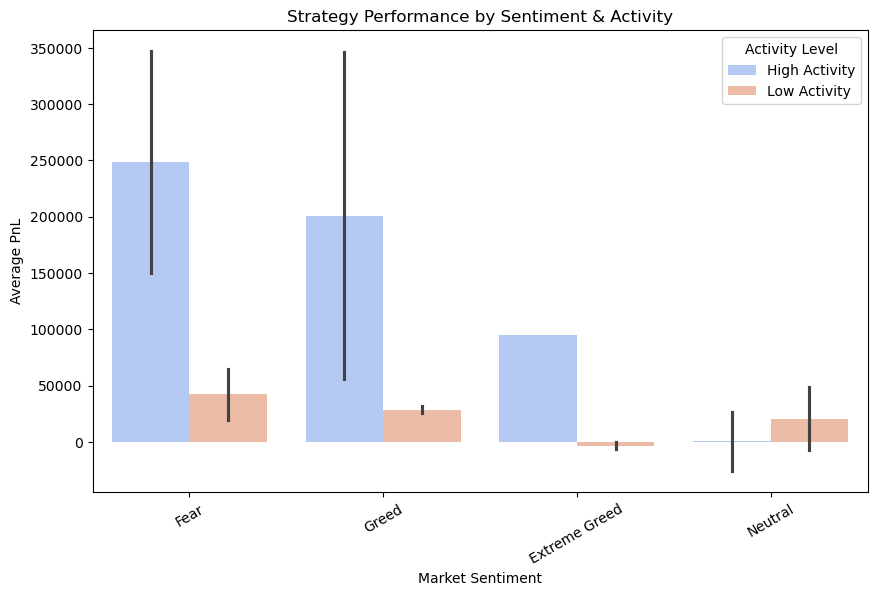

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='classification',
    y='avg_pnl',
    hue='activity_segment',
    data=strategy_table,
    palette='coolwarm'
)

plt.title("Strategy Performance by Sentiment & Activity")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.legend(title='Activity Level')
plt.xticks(rotation=30)
plt.savefig('Strategy Performance by Sentiment & Activity.png', dpi=300)
plt.show()

### <u>Strategy 1:</u> Maximize Activity During Fear Markets
#### Rule
- During **Fear markets**:
  - Increase trading frequency (high activity)
  - Maintain moderate to high position sizes

#### Evidence
- **Fear + High Activity + High Risk → ~347K avg PnL**
- **Fear + High Activity + Low Risk → ~150K avg PnL**
- High trading activity (~4000+ trades) consistently associated with top performance

#### Interpretation
- Fear markets create volatility and inefficiencies
- Active traders capitalize on frequent opportunities

* **Actionable Insight:**  
Increase participation during Fear — but maintain controlled risk.


### <u>Strategy 2:</u> Avoid Low Activity + High Risk (Especially in Extreme Greed & Neutral)
#### Rule
- Avoid taking large positions when:
  - Trading frequency is low
  - Market sentiment is **Extreme Greed or Neutral**

#### Evidence
- **Extreme Greed + Low Activity + High Risk → -6.7K PnL**
- **Neutral + High Activity + High Risk → -25.9K PnL**
- **Neutral + Low Activity + High Risk → -7.2K PnL**

#### Interpretation
- Large positions without sufficient participation increase downside risk
- Overconfidence (Greed) and lack of direction (Neutral) lead to poor outcomes

* **Actionable Insight:**  
Reduce risk exposure unless actively trading in favorable conditions.


### <u>Strategy 3:</u> Prefer High Activity with Controlled Risk in Greed Markets
#### Rule
- During **Greed markets**:
  - Maintain high trading activity
  - Prefer **low-to-moderate risk positions**

#### Evidence
- **Greed + High Activity + Low Risk → ~346K avg PnL (highest win rate ~49.7%)**
- Outperforms high-risk counterparts in Greed

#### Interpretation
- Bullish markets reward participation but punish over-leverage
- Balanced risk leads to more consistent returns

* **Actionable Insight:**  
In Greed phases, trade actively but avoid aggressive risk-taking.


### <u>Strategy 4:</u> Reduce Trading in Neutral Markets
#### Rule
- During **Neutral markets**:
  - Reduce trading frequency
  - Avoid high-risk strategies

#### Evidence
- Neutral segments show:
  - Low or negative PnL
  - Low consistency
- Worst performance includes:
  - High Activity + High Risk → negative returns

#### Interpretation
- Lack of clear market direction reduces opportunity
- Increased noise leads to poor decision-making

* **Actionable Insight:**  
Sit out or trade conservatively in Neutral conditions.


### <u>Overall Strategy Framework</u>
#### Best Conditions for Trading
- Fear + High Activity
- Greed + High Activity + Controlled Risk

#### Conditions to Avoid
- Low Activity + High Risk
- Neutral markets (especially high risk)


### Final Takeaway
Successful trading strategies are driven by:
- **Adapting to market sentiment**
- **Maintaining high engagement**
- **Managing risk dynamically**

The most effective traders:
- Trade actively in volatile markets (Fear)
- Control risk during bullish phases (Greed)
- Avoid unnecessary exposure in uncertain conditions (Neutral)

---

## BONUS — PREDICTIVE MODEL

In [25]:
# Target variable (classification)

daily_metrics['profit_label'] = (daily_metrics['daily_pnl'] > 0).astype(int)

# 1 = Profitable, 0 = Not Profitable

print(daily_metrics[['daily_pnl', 'profit_label']].head())

     daily_pnl  profit_label
0     0.000000             0
1     0.000000             0
2   155.503357             1
3 -5564.016140             0
4     0.000000             0


In [26]:
features = [
    'trades_count',
    'avg_trade_size',
    'total_volume',
    'win_rate',
    'long_ratio'
]

X = daily_metrics[features]

# Convert sentiment to numeric
X = pd.get_dummies(daily_metrics[['classification']]).join(X)

y = daily_metrics['profit_label']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
# Evaluate model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9375

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.93      1.00      0.96        13

    accuracy                           0.94        16
   macro avg       0.96      0.83      0.88        16
weighted avg       0.94      0.94      0.93        16



In [30]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                        feature  importance
7                      win_rate    0.403570
4                  trades_count    0.152594
8                    long_ratio    0.134362
6                  total_volume    0.097241
5                avg_trade_size    0.083362
3        classification_Neutral    0.053369
0  classification_Extreme Greed    0.045171
1           classification_Fear    0.015591
2          classification_Greed    0.014740


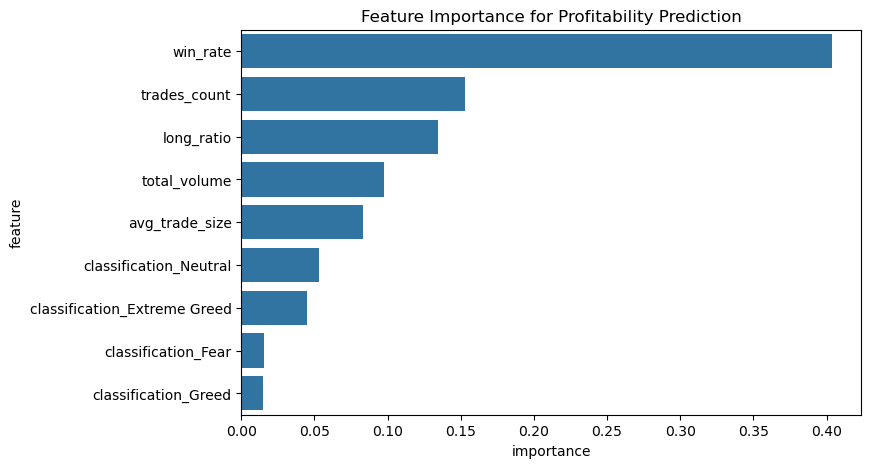

In [45]:
# Visualisation
plt.figure(figsize=(8,5))

sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance
)

plt.title("Feature Importance for Profitability Prediction")
plt.savefig('Feature Importance for Profitability Prediction.png', dpi=300)
plt.show()

### Objective
To predict whether a trader will be profitable based on trading behavior and market sentiment features.

### Model Approach
- Target Variable:
  - `profit_label` → 1 (Profitable), 0 (Not Profitable)

- Model Used:
  - Random Forest Classifier

- Features Used:
  - Trading behavior:
    - Number of trades
    - Average trade size
    - Total volume
    - Win rate
    - Long/Short ratio
  - Market sentiment:
    - Encoded classification (Fear, Greed, etc.)


### Model Performance
- **Accuracy: ~93.75%**
- Strong performance in identifying profitable traders

#### Classification Insights:
- High recall for profitable traders (1.00) → model captures winners effectively
- Slightly lower recall for non-profitable traders due to smaller sample size

* Overall, the model performs reliably despite limited data.


#### Feature Importance Analysis

| Feature | Importance |
|--------|-----------|
| **Win Rate** | **0.40** |
| Trades Count | 0.15 |
| Long Ratio | 0.13 |
| Total Volume | 0.09 |
| Avg Trade Size | 0.08 |
| Sentiment Features | Low |


### Key Findings

#### 1. Win Rate is the Most Important Predictor
- Highest importance (~40%)
- Strong indicator of trader skill and consistency

#### 2. Trading Activity Matters
- Trades count (~15%) is the second most important feature
- Confirms earlier insight: **activity drives performance**

#### 3. Directional Bias Plays a Role
- Long ratio (~13%) influences profitability
- Suggests positioning strategy matters

#### 4. Sentiment Has Lower Direct Impact
- Sentiment features have relatively low importance
- Indicates sentiment influences behavior indirectly rather than directly


### Conclusion
The predictive model demonstrates that trader profitability can be effectively estimated using behavioral features.

Key takeaway:
- **Skill (win rate) + activity (trade frequency) = strongest drivers of profitability**


### Business Implications
- Can be used for:
  - Trader performance scoring
  - Risk monitoring systems
  - Strategy optimization
  - Identifying high-potential traders


### Limitations
- Small dataset (77 observations) may limit generalization
- Model may overfit due to limited data
- Future improvements:
  - More historical data
  - Feature engineering (volatility, drawdown)
  - Time-based modeling

---